Henry Adams

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats


## Using Cook's distance to remove outliers

In [71]:
df = pd.read_csv('data/usina_with_outliers.csv')

print("Original dataset shape:", df.shape)
display(df.head())

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
n = len(y)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_mse = float('inf')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    if mse < best_mse:
        best_mse = mse
        best_alpha = alpha

model = Ridge(alpha=best_alpha)
model.fit(X, y)
y_pred = model.predict(X)

residuals = y - y_pred

mse = np.mean(residuals**2)

p = X.shape[1]  # number of features
X_centered = X - X.mean(axis=0)

# Calculate hat matrix for Ridge
XtX = X_centered.T @ X_centered
I = np.eye(p)
XtX_ridge_inv = np.linalg.inv(XtX + best_alpha * I)
H = X_centered @ XtX_ridge_inv @ X_centered.T
leverage = np.diag(H)

standardized_residuals = residuals / (np.sqrt(mse * (1 - leverage)))

# Compute Cook's Distance
# D_i = (r_i^2 / p) * (h_i / (1 - h_i))
# where r_i is standardized residual, h_i is leverage, p is number of parameters
cooks_distance = (standardized_residuals**2 / p) * (leverage / (1 - leverage))

print("\n" + "="*60)
print("Cook's Distance Statistics:")
print("="*60)
print(f"Mean Cook's Distance: {np.mean(cooks_distance):.6f}")
print(f"Max Cook's Distance:  {np.max(cooks_distance):.6f}")
print(f"Min Cook's Distance:  {np.min(cooks_distance):.6f}")

threshold = 4 / n
outlier_mask = cooks_distance > threshold

print(f"\nOutlier Detection Threshold: 4/n = 4/{n} = {threshold:.6f}")
print(f"Number of outliers detected: {np.sum(outlier_mask)}")
print(f"Percentage of outliers: {100 * np.sum(outlier_mask) / n:.2f}%")

df_clean = df[~outlier_mask].copy()

df_clean.to_csv('out/usina.csv', index=False)

Original dataset shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90



Cook's Distance Statistics:
Mean Cook's Distance: 0.002701
Max Cook's Distance:  1.599090
Min Cook's Distance:  0.000000

Outlier Detection Threshold: 4/n = 4/9568 = 0.000418
Number of outliers detected: 129
Percentage of outliers: 1.35%


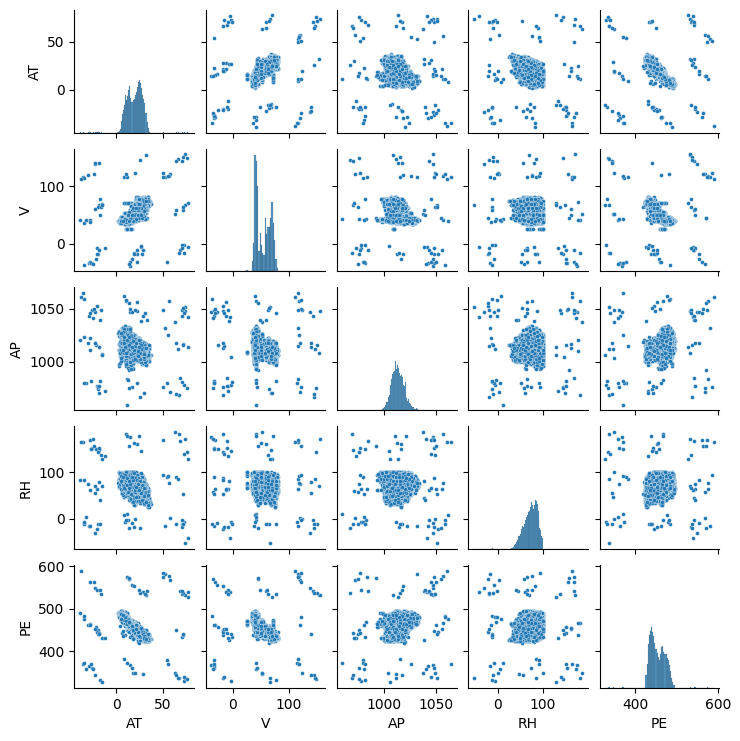

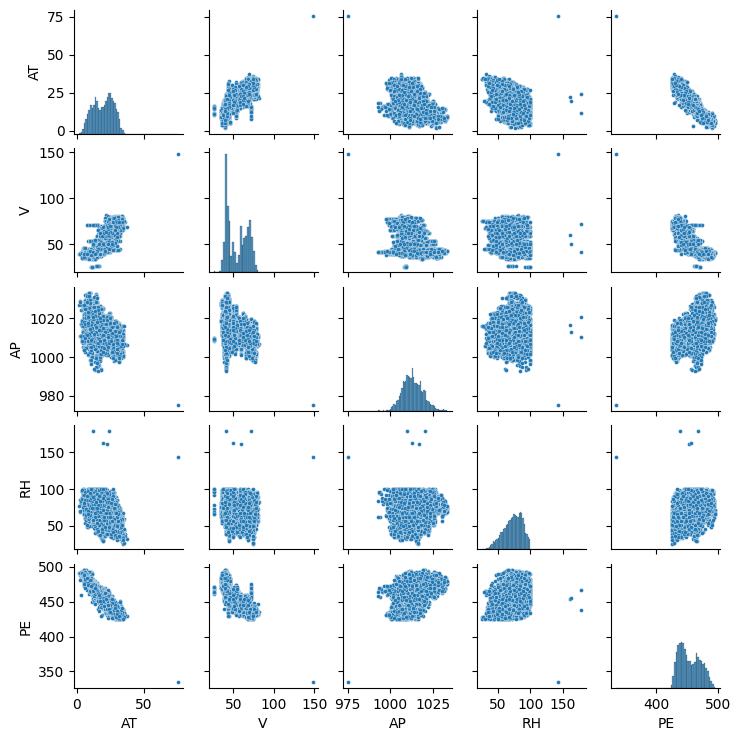

In [ ]:
sns.pairplot(df, height=1.5, plot_kws={'s': 8})
sns.pairplot(df_clean, height=1.5, plot_kws={'s': 8}) # notice the difference

Why did you choose this model?
- I chose Ridge Regression because it provides L2 regularization which helps 
stabilize the model when computing Cook's Distance, especially if there are correlated
features. Ridge is less likely to zero out coefficients compared to Lasso, which is
important for influence diagnostics. For outlier detection, we want all features to 
contribute to the influence calculation rather than having some eliminated by Lasso.

Why did you choose this library?
- I chose scikit-learn because it provides fast regression computation and 
straightforward prediction methods.

## Training models with/without Outlier Removal

Helper function below

In [73]:
def evaluate_models(df):
    """
    Train Linear, Ridge, and Lasso regression models and evaluate performance.
    """
    
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    
    results = []
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({
        'Model': 'Linear Regression',
        'Lambda': None,
        'Train MAE': train_mae,
        'Train MSE': train_mse,
        'Train R^2': train_r2,
        'Test MAE': test_mae,
        'Test MSE': test_mse,
        'Test R^2': test_r2
    })
    
    lambdas = [0.01, 0.1, 1, 10, 100]
    
    for lam in lambdas:
        model = Ridge(alpha=lam)
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_mse = mean_squared_error(y_train, y_train_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        results.append({
            'Model': 'Ridge Regression',
            'Lambda': lam,
            'Train MAE': train_mae,
            'Train MSE': train_mse,
            'Train R^2': train_r2,
            'Test MAE': test_mae,
            'Test MSE': test_mse,
            'Test R^2': test_r2
        })
    
    for lam in lambdas:
        model = Lasso(alpha=lam, max_iter=10000)
        model.fit(X_train, y_train)
        
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        train_mae = mean_absolute_error(y_train, y_train_pred)
        train_mse = mean_squared_error(y_train, y_train_pred)
        train_r2 = r2_score(y_train, y_train_pred)
        
        test_mae = mean_absolute_error(y_test, y_test_pred)
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        results.append({
            'Model': 'Lasso Regression',
            'Lambda': lam,
            'Train MAE': train_mae,
            'Train MSE': train_mse,
            'Train R^2': train_r2,
            'Test MAE': test_mae,
            'Test MSE': test_mse,
            'Test R^2': test_r2
        })
    
    return pd.DataFrame(results)

In [74]:
df_with_outliers = pd.read_csv('data/usina_with_outliers.csv')
df_clean = pd.read_csv('out/usina.csv')

results_with_outliers = evaluate_models(df_with_outliers)
results_clean = evaluate_models(df_clean)

print("RESULTS SUMMARY - Dataset with Outliers")
display(results_with_outliers)

print("RESULTS SUMMARY - Dataset without Outliers")
display(results_clean)


RESULTS SUMMARY - Dataset with Outliers


,Model,Lambda,Train MAE,Train MSE,Train R^2,Test MAE,Test MSE,Test R^2
0,Linear Regression,NaN,5.198679,123.384207,0.650171,5.052458,125.113389,0.642574
1,Ridge Regression,0.01,5.198679,123.384207,0.650171,5.052458,125.113389,0.642574
2,Ridge Regression,0.10,5.198680,123.384207,0.650171,5.052459,125.113392,0.642574
3,Ridge Regression,1.00,5.198685,123.384207,0.650171,5.052463,125.113421,0.642574
4,Ridge Regression,10.00,5.198737,123.384207,0.650171,5.052513,125.113705,0.642573
5,Ridge Regression,100.00,5.199261,123.384213,0.650171,5.053003,125.116548,0.642565
6,Lasso Regression,0.01,5.198858,123.384210,0.650171,5.052626,125.115332,0.642568
7,Lasso Regression,0.10,5.201739,123.384607,0.650169,5.055348,125.134495,0.642514
8,Lasso Regression,1.00,5.229507,123.421151,0.650066,5.083092,125.338356,0.641931
9,Lasso Regression,10.00,5.540418,126.141514,0.642353,5.408803,128.902136,0.631750


RESULTS SUMMARY - Dataset without Outliers


,Model,Lambda,Train MAE,Train MSE,Train R^2,Test MAE,Test MSE,Test R^2
0,Linear Regression,NaN,3.619906,20.310733,0.930137,3.584653,19.357649,0.932730
1,Ridge Regression,0.01,3.619906,20.310733,0.930137,3.584653,19.357649,0.932730
2,Ridge Regression,0.10,3.619906,20.310733,0.930137,3.584653,19.357648,0.932730
3,Ridge Regression,1.00,3.619909,20.310733,0.930137,3.584654,19.357632,0.932730
4,Ridge Regression,10.00,3.619942,20.310733,0.930137,3.584662,19.357475,0.932731
5,Ridge Regression,100.00,3.620271,20.310820,0.930137,3.584740,19.355991,0.932736
6,Lasso Regression,0.01,3.619877,20.310736,0.930137,3.584602,19.357607,0.932730
7,Lasso Regression,0.10,3.620454,20.311301,0.930135,3.584477,19.354786,0.932740
8,Lasso Regression,1.00,3.629939,20.373886,0.929920,3.587743,19.380963,0.932649
9,Lasso Regression,10.00,4.139387,26.380881,0.909258,4.016274,24.789740,0.913853


- Do outliers change train error? Test error?

Outliers change both train and test error - Train and Test MAE are in the 5.1-5.6 range for the dataset with outliers, and in the 3.5-4.2 range without outliers.

- Which dataset (with outliers vs without outliers) shows better generalization?

Interestingly, both show similar levels of "generalization", in that for both datasets, models perform approximately as well on the training and the testing data.

- Do Ridge/Lasso appear to help relative to standard linear regression?

For suitable (a.k.a. small enough) lambda values, Ridge/Lasso appears to offer no significant benefit when judging by Test MAE and R^2 values.

## Reliability of coefficients using Studentization

In [75]:
df = pd.read_csv('out/usina.csv')

print("Dataset shape:", df.shape)
display(df.head())

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
feature_names = df.columns[:-1].tolist()
target_name = df.columns[-1]

# Normalize (standardize) features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

model = LinearRegression()
model.fit(X_scaled, y_scaled)

# Get predictions and residuals
y_pred = model.predict(X_scaled)
residuals = y_scaled - y_pred

n = len(y_scaled)  # number of observations
p = X_scaled.shape[1]  # number of features

mse = np.sum(residuals**2) / (n - p - 1)

XtX_inv = np.linalg.inv(X_scaled.T @ X_scaled)
H = X_scaled @ XtX_inv @ X_scaled.T
leverage = np.diag(H)

# Calculate studentized residuals
studentized_residuals = residuals / (np.sqrt(mse * (1 - leverage)))

# Calculate standard errors for coefficients
se_coef = np.sqrt(np.diag(XtX_inv) * mse)

# Calculate t-statistics for coefficients
t_stats = model.coef_ / se_coef

p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p-1))

results = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_,
    'Std Error': se_coef,
    't-statistic': t_stats,
    'p-value': p_values,
})

# Sort by absolute t-statistic
results['abs_t'] = np.abs(results['t-statistic'])
results = results.sort_values('abs_t', ascending=False).drop('abs_t', axis=1)

display(results)
print()

most_reliable_idx = np.argmax(np.abs(t_stats))
least_reliable_idx = np.argmin(np.abs(t_stats))

print(f"Most reliable coefficient:  {feature_names[most_reliable_idx]}")
print(f"  Coefficient: {model.coef_[most_reliable_idx]:.6f}")
print(f"  t-statistic: {t_stats[most_reliable_idx]:.6f}")
print(f"  p-value: {p_values[most_reliable_idx]:.6e}")
print()
print(f"Least reliable coefficient: {feature_names[least_reliable_idx]}")
print(f"  Coefficient: {model.coef_[least_reliable_idx]:.6f}")
print(f"  t-statistic: {t_stats[least_reliable_idx]:.6f}")
print(f"  p-value: {p_values[least_reliable_idx]:.6e}")
print()

Dataset shape: (9439, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


,Feature,Coefficient,Std Error,t-statistic,p-value
0,AT,-0.854054,0.006656,-128.315438,0.000000e+00
3,RH,-0.129357,0.003511,-36.845917,0.000000e+00
1,V,-0.178030,0.005393,-33.013326,0.000000e+00
2,AP,0.026350,0.003309,7.964358,1.776357e-15



Most reliable coefficient:  AT
  Coefficient: -0.854054
  t-statistic: -128.315438
  p-value: 0.000000e+00

Least reliable coefficient: AP
  Coefficient: 0.026350
  t-statistic: 7.964358
  p-value: 1.776357e-15



- Why did you choose this model?

Since a regularized model didn't previously do any better than an unregularized linear regression, I chose the standard linear regression for simplicity.

- Why did you choose this library (Statsmodels vs scikit-learn)?

I'm using scikit-learn throughout the whole notebook for consistency.

- Would you scale IVs and/or DV for this coefficient reliability task?

I'm scaling both IVs and DVs so that the standardized coefficients are exactly the coefficients of the model.


## Feature Importance

In [76]:
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_,
    'Absolute Coefficient': np.abs(model.coef_)
}).sort_values('Absolute Coefficient', ascending=False)

print("Feature Importance (based on standardized coefficients)")
display(coefficients[['Feature', 'Coefficient']])

most_important_idx = np.argmax(np.abs(model.coef_))
least_important_idx = np.argmin(np.abs(model.coef_))

print("Most important feature:  " + feature_names[most_important_idx])
print(f"  Coefficient: {model.coef_[most_important_idx]:.6f}")
print()
print("Least important feature: " + feature_names[least_important_idx])
print(f"  Coefficient: {model.coef_[least_important_idx]:.6f}")

Feature Importance (based on standardized coefficients)


,Feature,Coefficient
0,AT,-0.854054
1,V,-0.178030
3,RH,-0.129357
2,AP,0.026350


Most important feature:  AT
  Coefficient: -0.854054

Least important feature: AP
  Coefficient: 0.026350


- Why did you choose this model?

I used the same model as in the previous part so for consistency.

- Why did you choose this library (Statsmodels vs scikit-learn)?

I'm using scikit-learn throughout the whole notebook for consistency.

- Would you scale IVs and/or DV for this feature importance task?

Scaling IVs is required here, since otherwise coefficient weights will be influenced by the size/magnitude of the preprocessed features. I also scale the DV, but this is more or less optional.

## Regularization on Z-normalized data

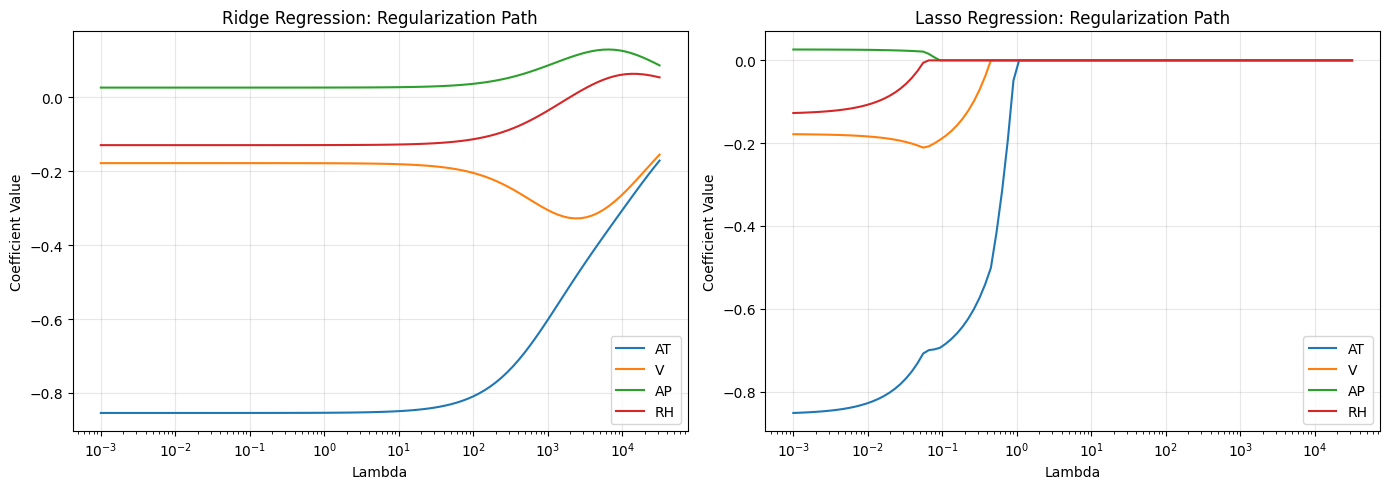

In [77]:
lambdas = np.logspace(-3, 4.5, 100)

ridge_coefs = []
lasso_coefs = []

for lam in lambdas:
    ridge_model = Ridge(alpha=lam)
    ridge_model.fit(X_scaled, y_scaled)
    ridge_coefs.append(ridge_model.coef_)
    
    lasso_model = Lasso(alpha=lam, max_iter=10000)
    lasso_model.fit(X_scaled, y_scaled)
    lasso_coefs.append(lasso_model.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge plot
for i in range(len(feature_names)):
    axes[0].plot(lambdas, ridge_coefs[:, i], label=feature_names[i])
axes[0].set_xscale('log')
axes[0].set_xlabel('Lambda')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge Regression: Regularization Path')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Lasso plot
for i in range(len(feature_names)):
    axes[1].plot(lambdas, lasso_coefs[:, i], label=feature_names[i])
axes[1].set_xscale('log')
axes[1].set_xlabel('Lambda')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso Regression: Regularization Path')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- What happens to coefficients as lambda increases in Ridge vs Lasso?

Coefficients in the Lasso model shrink to zero faster than for Ridge as lambda increases (intuitively, this occurs because an L1 regularization penalizes a small nonzero coefficient more than L2 regularization with the same lambda value)

- Which regression is better under multicollinearity in IVs, and why?

Empirically, Ridge regressions perform better when different IVs are highly correlated (i.e. the dataset has multicollinearity). Answering "why" is quite complicated...

- Which regression is better for feature selection, and why?

Lasso regression helps with "feature selection", since it tends to drive less important coefficients to zero, meaining that the regression coefficients are sparse for higher lambda values.